In [1]:
#### start interactive session in terminal before any heavy lifting
## interact -n 12 -t 08:00:00 -m 64g
import socket
print(socket.gethostname())

vscode1.oscar.ccv.brown.edu


In [ ]:


import os
import torch
from torch.utils.data import Dataset, DataLoader
from model_VAE import JetDeepSetVAE
from particleloader import load
import numpy as np
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


def vae_loss(x, mask, xhat, mu, logv, beta=1e-3):
    m = mask.unsqueeze(-1)
    recon = ((x - xhat)**2 * m).sum() / m.sum().clamp_min(1.0)

    kl = -0.5 * torch.sum(1 + logv - mu.pow(2) - logv.exp(), dim=1).mean()
    return recon + beta * kl, recon, kl

Using device: cpu


In [5]:
N = 1000
dir = "work"
jets, labels = load("qg_jets", N, cache_dir=dir)

In [6]:
mask = (jets[:,:,0] > 0).astype(np.float32)
print(mask.shape)
print(mask[0])

(1000, 139)
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [7]:
class JetDataset(Dataset):

    def __init__(self, jets, mask):
        self.jets = torch.tensor(jets, dtype=torch.float32)
        self.mask = torch.tensor(mask, dtype=torch.float32)

    def __len__(self):
        return len(self.jets)

    def __getitem__(self, idx):
        return self.jets[idx], self.mask[idx]

In [8]:
dataset = JetDataset(jets[:, :, :3], mask)

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,
    drop_last=True,
    num_workers=4
)

In [ ]:
model = JetDeepSetVAE(
    din=3,
    nmax=jets.shape[1],
    zdim=200
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 20

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for x, mask_batch in loader:
        x = x.to(device)
        mask_batch = mask_batch.to(device)

        optimizer.zero_grad()

        xhat, mu, logv, z = model(x, mask_batch)
        loss, recon, kl = vae_loss(x, mask_batch, xhat, mu, logv, beta=1e-3)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"epoch {epoch:02d}  loss={running_loss / len(loader):.6f}")

epoch 00  loss=685.930945
epoch 01  loss=538.318339
epoch 02  loss=515.088643
epoch 03  loss=516.659469
epoch 04  loss=503.588702
epoch 05  loss=1203.078355
epoch 06  loss=504.871942
epoch 07  loss=489.255300
epoch 08  loss=476.750649
epoch 09  loss=481.554148
epoch 10  loss=465.928072
epoch 11  loss=445.627753
epoch 12  loss=435.146080
epoch 13  loss=431.116337
epoch 14  loss=412.935830
epoch 15  loss=406.217737
epoch 16  loss=396.323305
epoch 17  loss=390.103158
epoch 18  loss=389.434503
epoch 19  loss=397.821556


In [11]:
eval_loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=False,
    drop_last=False
)

In [12]:
model.eval()

all_x = []
all_xhat = []
all_mask = []
all_mu = []

with torch.no_grad():
    for x, mask_batch in eval_loader:
        x = x.to(device)
        mask_batch = mask_batch.to(device)

        xhat, mu, logv, z = model(x, mask_batch)

        all_x.append(x.cpu())
        all_xhat.append(xhat.cpu())
        all_mask.append(mask_batch.cpu())
        all_mu.append(mu.cpu())

all_x = torch.cat(all_x, dim=0).numpy()
all_xhat = torch.cat(all_xhat, dim=0).numpy()
all_mask = torch.cat(all_mask, dim=0).numpy()
all_mu = torch.cat(all_mu, dim=0).numpy()

print(all_x.shape)
print(all_xhat.shape)
print(all_mask.shape)
print(all_mu.shape)

(1000, 139, 3)
(1000, 139, 3)
(1000, 139)
(1000, 200)


In [13]:
def jets_from_constituents(p, mask):
    pt  = p[:, :, 0] * mask
    eta = p[:, :, 1]
    phi = p[:, :, 2]

    E  = np.sum(pt * np.cosh(eta) * mask, axis=1)
    px = np.sum(pt * np.cos(phi) * mask, axis=1)
    py = np.sum(pt * np.sin(phi) * mask, axis=1)
    pz = np.sum(pt * np.sinh(eta) * mask, axis=1)

    jet_pt = np.sqrt(px**2 + py**2)
    jet_phi = np.arctan2(py, px)

    pabs = np.sqrt(px**2 + py**2 + pz**2)
    jet_eta = 0.5 * np.log((pabs + pz + 1e-12) / (pabs - pz + 1e-12))

    return jet_pt, jet_eta, jet_phi

In [14]:
pt_true, eta_true, phi_true = jets_from_constituents(all_x, all_mask)
pt_reco, eta_reco, phi_reco = jets_from_constituents(all_xhat, all_mask)

pt_ratio = pt_reco / (pt_true + 1e-12)
eta_diff = eta_reco - eta_true
phi_diff = np.arctan2(np.sin(phi_reco - phi_true), np.cos(phi_reco - phi_true))

/tmp/ipykernel_1187243/1570003958.py:6: RuntimeWarning: overflow encountered in cosh
  E  = np.sum(pt * np.cosh(eta) * mask, axis=1)
/tmp/ipykernel_1187243/1570003958.py:6: RuntimeWarning: invalid value encountered in multiply
  E  = np.sum(pt * np.cosh(eta) * mask, axis=1)
/tmp/ipykernel_1187243/1570003958.py:9: RuntimeWarning: overflow encountered in sinh
  pz = np.sum(pt * np.sinh(eta) * mask, axis=1)
/tmp/ipykernel_1187243/1570003958.py:9: RuntimeWarning: invalid value encountered in multiply
  pz = np.sum(pt * np.sinh(eta) * mask, axis=1)


[0.79104257 0.7459153  1.0155926  1.2999872  1.4658084  1.0010402
 0.47259048 1.2110044  1.3487223  0.8545138  0.8781102  1.120186
 1.3566467  1.0709131  0.9727441  1.155542   1.299898   1.0452408
 1.3358966  1.0002306  1.1024815  0.8549756  0.6507142  0.9083805
 1.3833027  1.1719663  1.3327402  1.0138328  1.221439   1.1310142
 1.0966212  0.81763005 1.173942   1.0527076  1.040508   0.8466036
 1.0668309  1.0797381  0.6887584  0.9949357  1.2327667  1.1082118
 1.0010937  0.58259445 0.8625438  1.1323383  1.073546   0.92476994
 0.9954624  1.0818083  1.0426549  0.7706554  1.3105031  0.9935134
 1.0386311  1.0984783  0.7394391  0.78212917 0.81126106 0.7064914
 0.75096756 1.2265543  0.7434779  1.1917608  1.2993108  1.2152728
 1.1934977  1.1097009  0.9530527  0.83678585 1.0387734  0.79235303
 0.69840604 1.2482669  1.0155197  1.1806897  0.8547784  1.2899443
 1.4701729  1.2674567  0.8314531  1.1344274  0.9289922  1.1568487
 1.0714319  1.259029   1.0205742  1.184689   0.88281894 1.4224684
 1.103814

(1000,)
(1000, 139)
[[  2.222376    2.315912    1.7258992 ...  -3.6212811   1.4682745
    1.2082796]
 [  1.9432876   2.0763636   1.8322407 ...  -5.340264    2.1210163
    1.4401505]
 [  1.9172503   2.2260284   2.0115628 ...  -6.57719     2.4829557
    1.5476003]
 ...
 [  1.9104551   2.0344958   1.7561166 ...  -4.957355    1.9517672
    1.3765264]
 [  1.9062916   2.3012292   2.008626  ...  -7.5084333   2.7929199
    1.6163934]
 [  1.7149367   2.8266218   2.0162654 ... -14.60511     5.9102693
    2.4842956]]


/tmp/ipykernel_1187243/2887082507.py:33: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0,1e5)


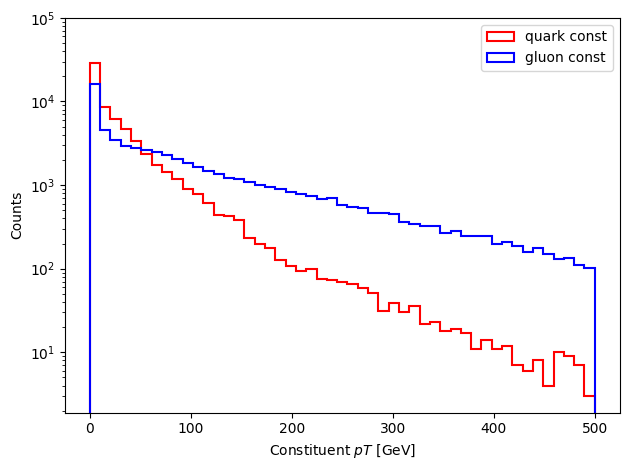

In [15]:
### plot 
import matplotlib.pyplot as plt
bins = np.linspace(0, 500, 50) 
labels = np.array(labels).astype(int)
mask = (labels == 0)
pt  = all_xhat[..., 0]
print(labels.shape)
print(pt.shape)
print(pt[mask])
plt.hist(
            pt[mask].reshape(-1),
            bins=bins,
            histtype="step",
            linewidth=1.5,
            label="quark const",
            color="red"
        )
mask = (labels != 0)
plt.hist(
            pt[mask].reshape(-1),
            bins=bins,
            histtype="step",
            linewidth=1.5,
            label="gluon const",
            color="blue"
        )
        

plt.xlabel("Constituent $pT$ [GeV]")
plt.ylabel("Counts")
plt.legend()
plt.yscale("log")
plt.ylim(0,1e5)
plt.tight_layout()
plt.show()

(1000,)
(1000, 139)
[[7.7024503  0.20737717 1.1428177  ... 0.         0.         0.        ]
 [1.0369061  0.31846768 0.7574478  ... 0.         0.         0.        ]
 [3.2928255  4.3360248  3.5872235  ... 0.         0.         0.        ]
 ...
 [0.19463567 2.1425984  0.97380346 ... 0.         0.         0.        ]
 [0.35105377 0.4902825  0.05204733 ... 0.         0.         0.        ]
 [3.4948137  2.7170248  0.50707877 ... 0.         0.         0.        ]]


/tmp/ipykernel_1187243/1567334900.py:33: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0,1e5)


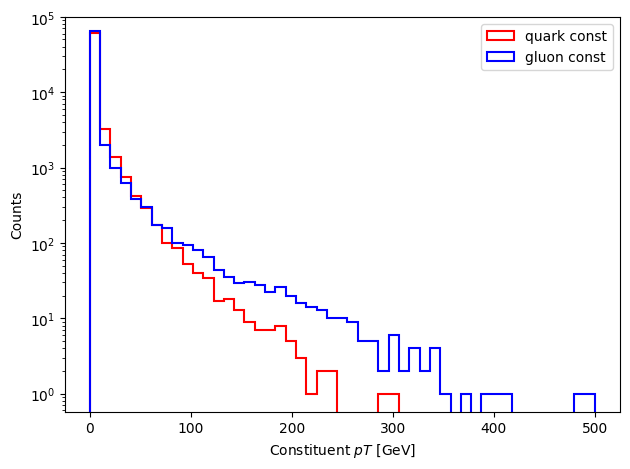

In [16]:
### plot 
import matplotlib.pyplot as plt
bins = np.linspace(0, 500, 50) 
labels = np.array(labels).astype(int)
mask = (labels == 0)
pt  = all_x[..., 0]
print(labels.shape)
print(pt.shape)
print(pt[mask])
plt.hist(
            pt[mask].reshape(-1),
            bins=bins,
            histtype="step",
            linewidth=1.5,
            label="quark const",
            color="red"
        )
mask = (labels != 0)
plt.hist(
            pt[mask].reshape(-1),
            bins=bins,
            histtype="step",
            linewidth=1.5,
            label="gluon const",
            color="blue"
        )
        

plt.xlabel("Constituent $pT$ [GeV]")
plt.ylabel("Counts")
plt.legend()
plt.yscale("log")
plt.ylim(0,1e5)
plt.tight_layout()
plt.show()